In [1]:
import pandas as pd


df_CC = pd.read_csv("C:/Users/lenovo/OneDrive/Documents/PROJEK MANDIRI/Deteksi Anomali Transaksi Sistem Pembayaran Digital/data/raw/creditcard.csv")
df_CC.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Data Understanding

In [2]:
print(f"Total baris data: {df_CC.shape[0]:,}")
print(f"Total kolom/fitur: {df_CC.shape[1]}")
print(f"\nTipe data setiap kolom:")
print(df_CC.dtypes.value_counts())

Total baris data: 284,807
Total kolom/fitur: 31

Tipe data setiap kolom:
float64    30
int64       1
Name: count, dtype: int64


In [3]:
print("----Cek Missing Value---")
missing_values = df_CC.isnull().sum()
missing_percentage = (missing_values / len(df_CC)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("Tidak ada missing values dalam dataset!")

----Cek Missing Value---
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
Tidak ada missing values dalam dataset!


In [69]:
print("---------Cek Duplikat Data--------")
duplicates = df_CC.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df_CC))*100:.4f}%")

if duplicates > 0:
    df_CC = df_CC.drop_duplicates()
    print(f"OK, Duplicate rows removed! New shape: {df_CC.shape}")

---------Cek Duplikat Data--------
Total duplicate rows: 1081
Percentage of duplicates: 0.3796%
OK, Duplicate rows removed! New shape: (283726, 31)


In [4]:
memory_usage = df_CC.memory_usage(deep=True).sum() / 1024**2  # Convert to MB
print(f"Total memory usage: {memory_usage:.2f} MB")
print("\nMemory usage per column:")
for col in df_CC.columns:
    mem_usage = df_CC[col].memory_usage(deep=True) / 1024**2
    print(f"  {col}: {mem_usage:.4f} MB")

Total memory usage: 67.36 MB

Memory usage per column:
  Time: 2.1730 MB
  V1: 2.1730 MB
  V2: 2.1730 MB
  V3: 2.1730 MB
  V4: 2.1730 MB
  V5: 2.1730 MB
  V6: 2.1730 MB
  V7: 2.1730 MB
  V8: 2.1730 MB
  V9: 2.1730 MB
  V10: 2.1730 MB
  V11: 2.1730 MB
  V12: 2.1730 MB
  V13: 2.1730 MB
  V14: 2.1730 MB
  V15: 2.1730 MB
  V16: 2.1730 MB
  V17: 2.1730 MB
  V18: 2.1730 MB
  V19: 2.1730 MB
  V20: 2.1730 MB
  V21: 2.1730 MB
  V22: 2.1730 MB
  V23: 2.1730 MB
  V24: 2.1730 MB
  V25: 2.1730 MB
  V26: 2.1730 MB
  V27: 2.1730 MB
  V28: 2.1730 MB
  Amount: 2.1730 MB
  Class: 2.1730 MB


Statistik Data

In [5]:
df_CC.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
class_distribution = df_CC['Class'].value_counts()
class_percentage = df_CC['Class'].value_counts(normalize=True) * 100

print(f"Non-Fraud (Class 0): {class_distribution[0]:,} ({class_percentage[0]:.4f}%)")
print(f"Fraud (Class 1): {class_distribution[1]:,} ({class_percentage[1]:.4f}%)")


Non-Fraud (Class 0): 284,315 (99.8273%)
Fraud (Class 1): 492 (0.1727%)


In [7]:
df_CC["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
imbalance_ratio = class_distribution[0] / class_distribution[1]
print(f"\nImbalance Ratio (Normal:Fraud): {imbalance_ratio:.2f}:1")
print(f"Artinya: Untuk setiap 1 transaksi fraud, terdapat {imbalance_ratio:.0f} transaksi normal")


Imbalance Ratio (Normal:Fraud): 577.88:1
Artinya: Untuk setiap 1 transaksi fraud, terdapat 578 transaksi normal


In [9]:
# Statistical analysis
from scipy.stats import zscore, ttest_ind, chi2_contingency

In [10]:
fraud_data = df_CC[df_CC['Class'] == 1]
non_fraud_data = df_CC[df_CC['Class'] == 0]

# Buat dataframe untuk perbandingan
comparison_stats = pd.DataFrame()
for col in ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]:
    if col in df_CC.columns:
        comparison_stats.loc[col, 'Non-Fraud_Mean'] = non_fraud_data[col].mean()
        comparison_stats.loc[col, 'Fraud_Mean'] = fraud_data[col].mean()
        comparison_stats.loc[col, 'Mean_Difference'] = fraud_data[col].mean() - non_fraud_data[col].mean()
        comparison_stats.loc[col, 'Mean_Difference_Pct'] = ((fraud_data[col].mean() - non_fraud_data[col].mean()) / non_fraud_data[col].mean()) * 100
        
        # T-test untuk signifikansi
        t_stat, p_value = ttest_ind(non_fraud_data[col].dropna(), fraud_data[col].dropna(), equal_var=False)
        comparison_stats.loc[col, 'T-Statistic'] = t_stat
        comparison_stats.loc[col, 'P-Value'] = p_value
        comparison_stats.loc[col, 'Significant'] = p_value < 0.05

# Tampilkan 10 fitur dengan perbedaan mean terbesar
print("Top 10 features dengan perbedaan mean terbesar:")
top_diff = comparison_stats['Mean_Difference'].abs().sort_values(ascending=False).head(10)
print(comparison_stats.loc[top_diff.index][['Non-Fraud_Mean', 'Fraud_Mean', 'Mean_Difference', 'P-Value', 'Significant']])

Top 10 features dengan perbedaan mean terbesar:
        Non-Fraud_Mean    Fraud_Mean  Mean_Difference        P-Value  \
Time      94838.202258  80746.806911    -14091.395347   1.654564e-10   
Amount       88.291022    122.211321        33.920299   3.560519e-03   
V3            0.012171     -7.033281        -7.045452   4.786081e-75   
V14           0.012064     -6.971723        -6.983787  1.040151e-140   
V17           0.011535     -6.665836        -6.677371   1.558094e-71   
V12           0.010832     -6.259393        -6.270225  1.481317e-112   
V10           0.009824     -5.676883        -5.686707   3.382884e-93   
V7            0.009637     -5.568731        -5.578368   4.292231e-52   
V1            0.008258     -4.771948        -4.780206   5.491643e-45   
V4           -0.007860      4.542029         4.549889  4.587317e-136   

       Significant  
Time          True  
Amount        True  
V3            True  
V14           True  
V17           True  
V12           True  
V10         

In [11]:
correlation_matrix = df_CC.corr()
correlation_with_target = correlation_matrix['Class'].sort_values(ascending=False)

print("Top 10 fitur paling berkorelasi POSITIF dengan Fraud:")
print(correlation_with_target.head(10))
print("\nTop 10 fitur paling berkorelasi NEGATIF dengan Fraud:")
print(correlation_with_target.tail(10))

Top 10 fitur paling berkorelasi POSITIF dengan Fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top 10 fitur paling berkorelasi NEGATIF dengan Fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


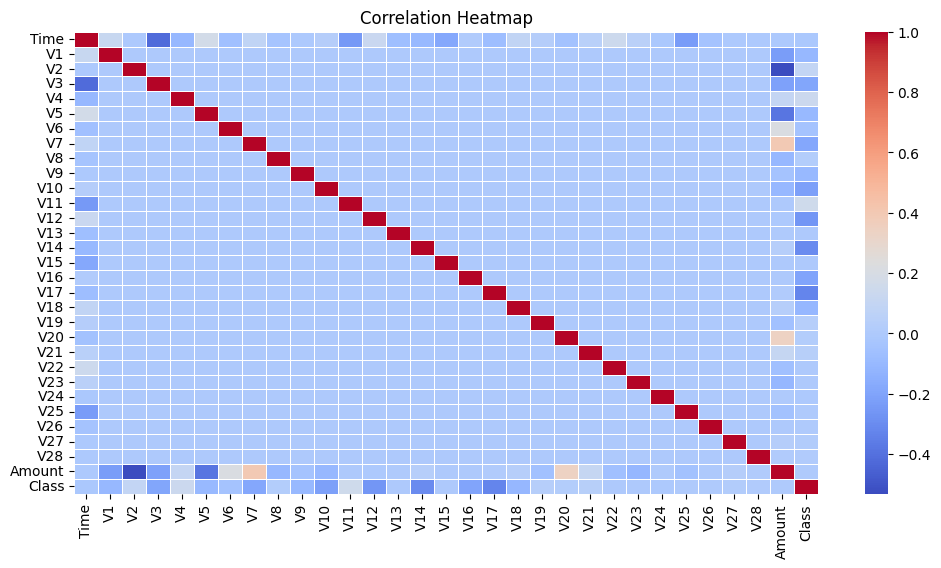

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df_CC.corr(), cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap")
plt.show()


Preprocessing Data

In [13]:
df_credit_original = df_CC.copy()
print(f"Original dataset shape: {df_credit_original.shape}")

Original dataset shape: (284807, 31)


In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

amount_outliers, lower_bound, upper_bound = detect_outliers_iqr(df_CC, 'Amount')
print(f"Outliers in 'Amount': {len(amount_outliers)} ({len(amount_outliers)/len(df_CC)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")


Outliers in 'Amount': 31904 (11.20%)
Lower bound: -101.75, Upper bound: 184.51


In [15]:
import joblib
amount_lower = df_CC['Amount'].quantile(0.01)
amount_upper = df_CC['Amount'].quantile(0.99)

df_CC['Amount_winsorized'] = df_CC['Amount'].clip(
    lower=amount_lower,
    upper=amount_upper
)

joblib.dump(amount_lower, "amount_lower_bound.pkl")
joblib.dump(amount_upper, "amount_upper_bound.pkl")

['amount_upper_bound.pkl']

# EDA

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

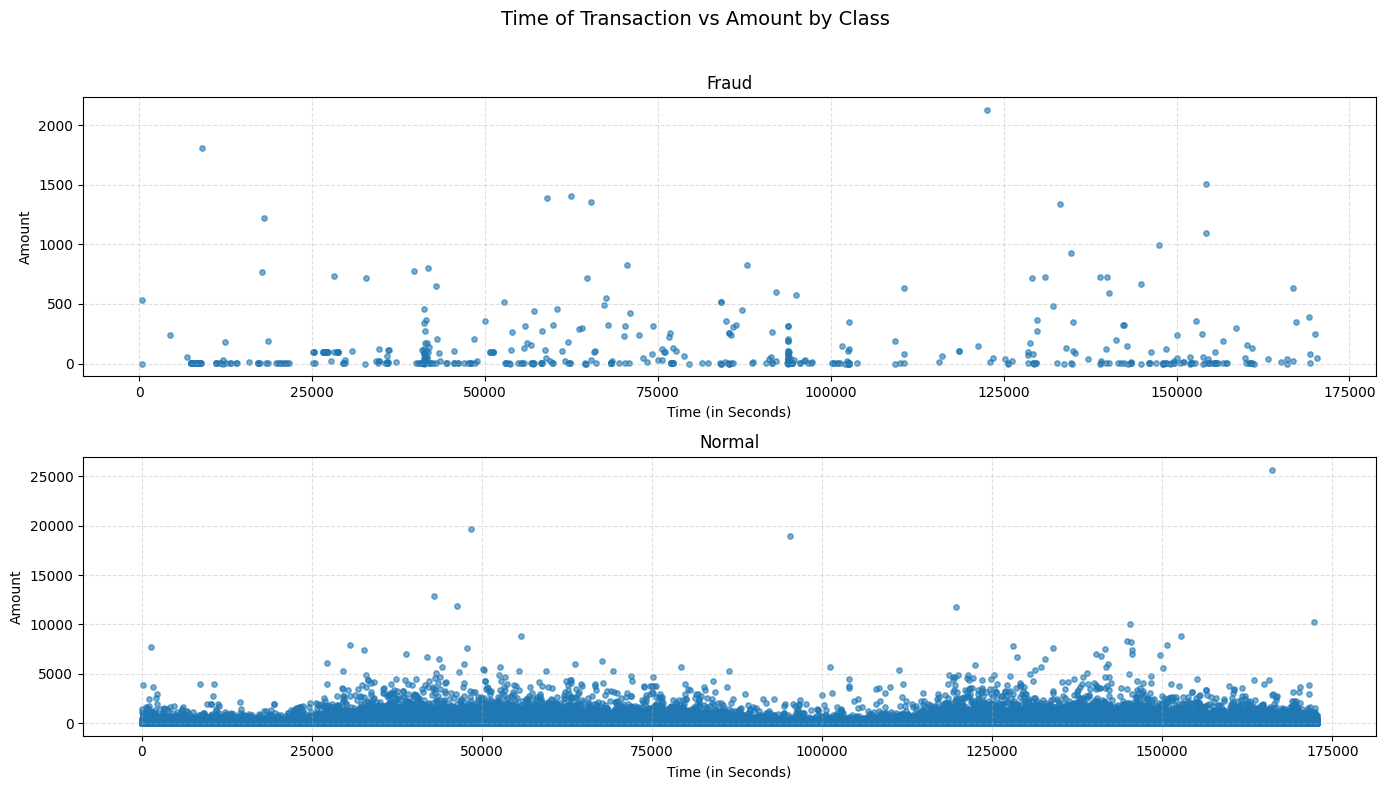

In [17]:
import matplotlib.pyplot as plt

# Pisahkan data berdasarkan kelas
fraud = df_CC[df_CC['Class'] == 1]
normal = df_CC[df_CC['Class'] == 0]

# Buat figure dengan 2 subplot (vertikal)
plt.figure(figsize=(14, 8))

# ===== FRAUD =====
plt.subplot(2, 1, 1)
plt.scatter(
    fraud['Time'],
    fraud['Amount'],
    alpha=0.6,
    s=15
)
plt.title("Fraud")
plt.ylabel("Amount")
plt.xlabel("Time (in Seconds)")
plt.grid(True, linestyle='--', alpha=0.4)

# ===== NORMAL =====
plt.subplot(2, 1, 2)
plt.scatter(
    normal['Time'],
    normal['Amount'],
    alpha=0.6,
    s=15
)
plt.title("Normal")
plt.ylabel("Amount")
plt.xlabel("Time (in Seconds)")
plt.grid(True, linestyle='--', alpha=0.4)

# Judul utama
plt.suptitle("Time of Transaction vs Amount by Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


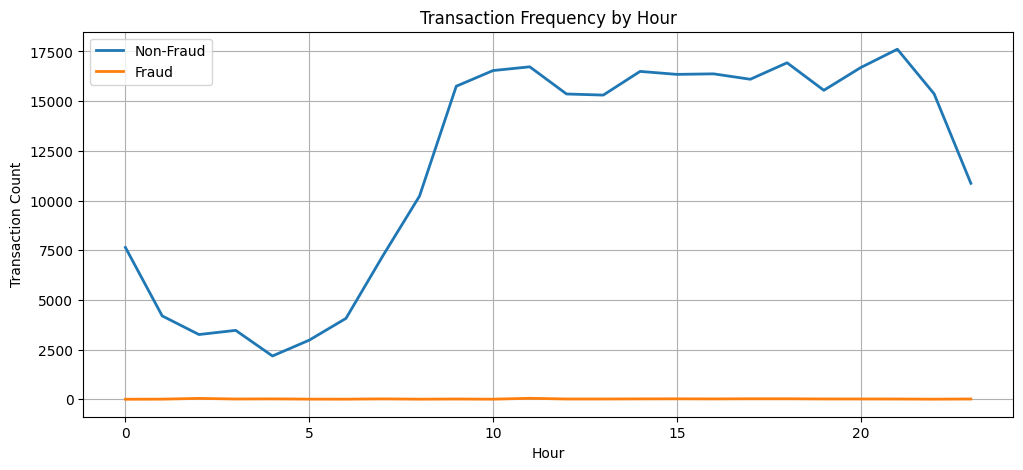

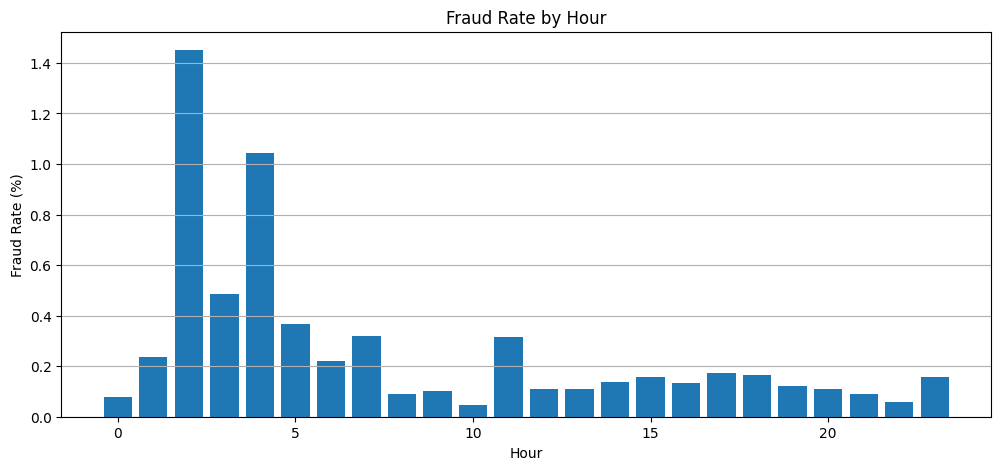

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. Membuat fitur jam (hour)
# ==============================
# Time dalam dataset CreditCard adalah detik
df_CC['hour'] = (df_CC['Time'] // 3600) % 24

# ==============================
# 2. Transaction Frequency by Hour
# ==============================
hourly_count = (
    df_CC
    .groupby(['hour', 'Class'])
    .size()
    .reset_index(name='count')
)

pivot_freq = hourly_count.pivot(
    index='hour',
    columns='Class',
    values='count'
).fillna(0)

plt.figure(figsize=(12,5))
plt.plot(pivot_freq.index, pivot_freq[0], label='Non-Fraud', linewidth=2)
plt.plot(pivot_freq.index, pivot_freq[1], label='Fraud', linewidth=2)
plt.xlabel('Hour')
plt.ylabel('Transaction Count')
plt.title('Transaction Frequency by Hour')
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# 3. Fraud Rate by Hour
# ==============================
total_per_hour = df_CC.groupby('hour').size()
fraud_per_hour = df_CC[df_CC['Class'] == 1].groupby('hour').size()

fraud_rate = (fraud_per_hour / total_per_hour).fillna(0) * 100

plt.figure(figsize=(12,5))
plt.bar(fraud_rate.index, fraud_rate.values)
plt.xlabel('Hour')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour')
plt.grid(axis='y')
plt.show()


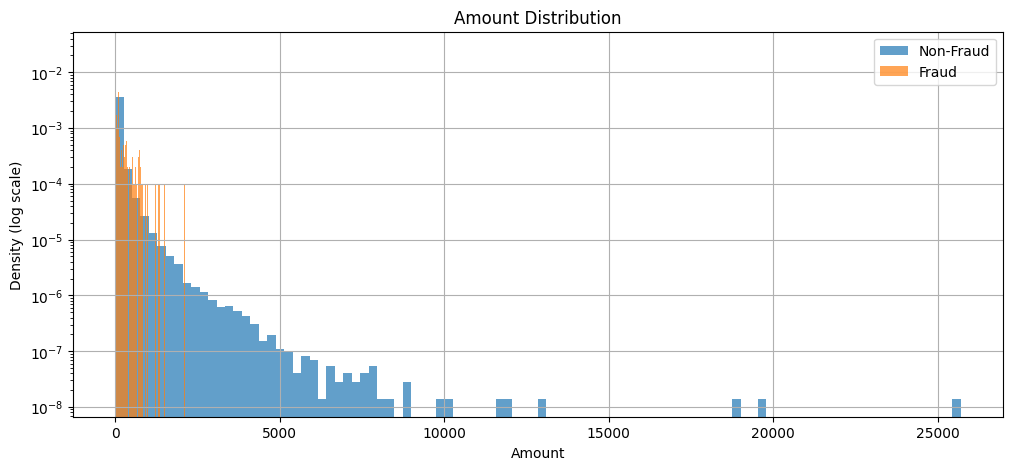

In [39]:
import matplotlib.pyplot as plt

# Pisahkan data berdasarkan class
amount_normal = df_CC[df_CC['Class'] == 0]['Amount']
amount_fraud = df_CC[df_CC['Class'] == 1]['Amount']

plt.figure(figsize=(12,5))

plt.hist(
    amount_normal,
    bins=100,
    alpha=0.7,
    label='Non-Fraud',
    density=True
)

plt.hist(
    amount_fraud,
    bins=100,
    alpha=0.7,
    label='Fraud',
    density=True
)

plt.yscale('log')
plt.xlabel('Amount')
plt.ylabel('Density (log scale)')
plt.title('Amount Distribution')
plt.legend()
plt.grid(True)

plt.show()


<Figure size 600x500 with 0 Axes>

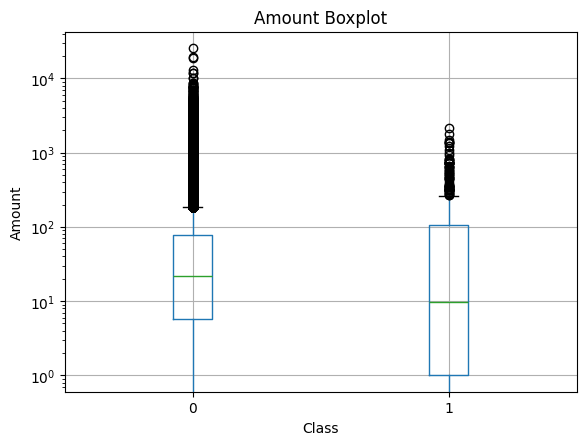

In [40]:
plt.figure(figsize=(6,5))

df_CC.boxplot(
    column='Amount',
    by='Class',
    grid=True,
    showfliers=True
)

plt.yscale('log')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.title('Amount Boxplot')
plt.suptitle('')  # Menghapus judul otomatis pandas

plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_22456\2672089610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df_CC, palette='coolwarm')


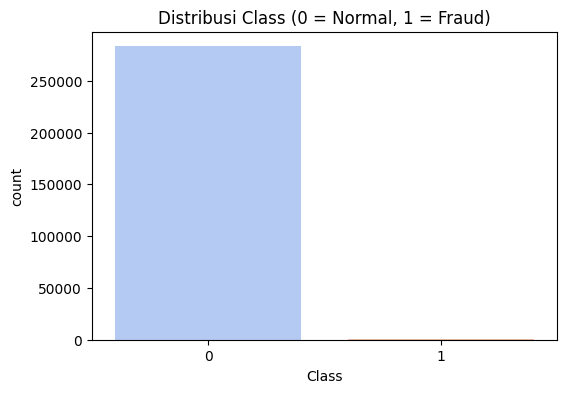

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df_CC, palette='coolwarm')
plt.title("Distribusi Class (0 = Normal, 1 = Fraud)")
plt.show()


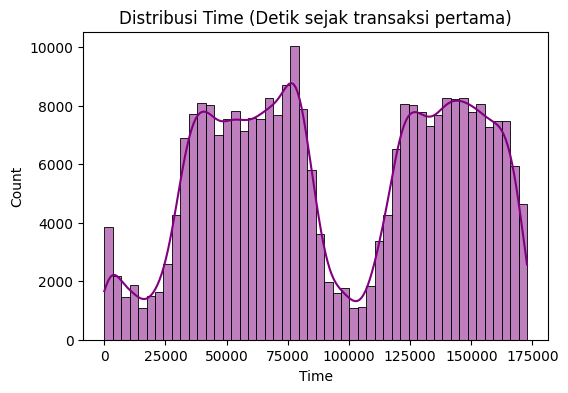

In [42]:
plt.figure(figsize=(6,4))
sns.histplot(df_CC['Time'], bins=50, kde=True, color="purple")
plt.title("Distribusi Time (Detik sejak transaksi pertama)")
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_22456\2334003768.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_CC[df_CC['Class']==1]['Time'], shade=True, label="Fraud")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_22456\2334003768.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_CC[df_CC['Class']==0]['Time'], shade=True, label="Normal")


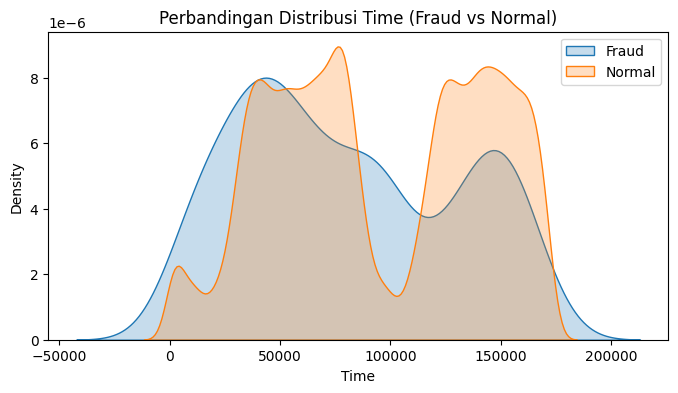

In [43]:
plt.figure(figsize=(8,4))
sns.kdeplot(df_CC[df_CC['Class']==1]['Time'], shade=True, label="Fraud")
sns.kdeplot(df_CC[df_CC['Class']==0]['Time'], shade=True, label="Normal")
plt.title("Perbandingan Distribusi Time (Fraud vs Normal)")
plt.legend()
plt.show()


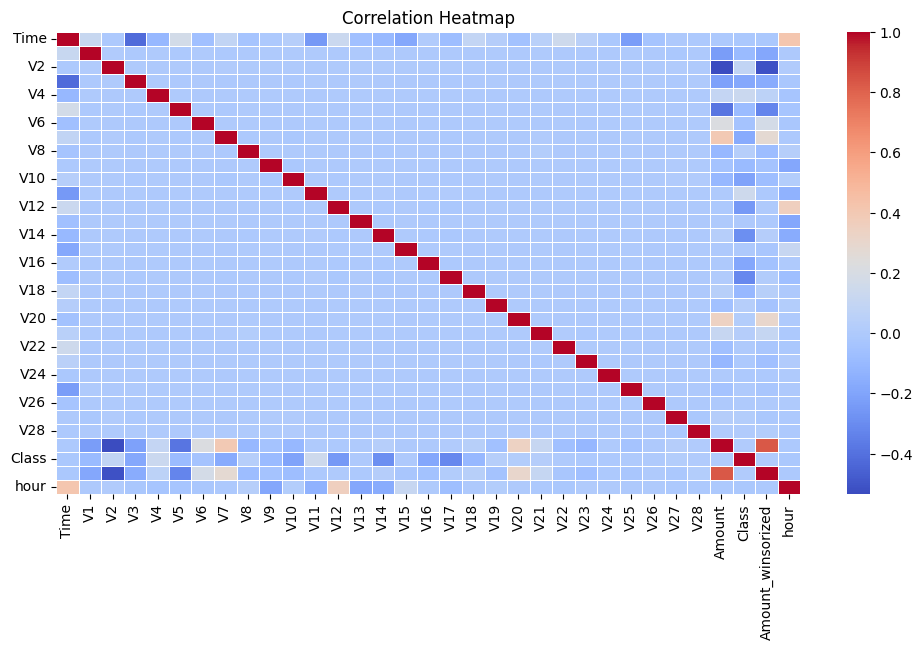

In [44]:
plt.figure(figsize=(12,6))
sns.heatmap(df_CC.corr(), cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap")
plt.show()


In [45]:
corr = df_CC.corr()['Class'].abs().sort_values(ascending=False).head(10)
print("\n=== TOP 10 FEATURES BERDASARKAN KORELASI DENGAN CLASS ===")
print(corr)



=== TOP 10 FEATURES BERDASARKAN KORELASI DENGAN CLASS ===
Class    1.000000
V17      0.313498
V14      0.293375
V12      0.250711
V10      0.206971
V16      0.187186
V3       0.182322
V7       0.172347
V11      0.149067
V4       0.129326
Name: Class, dtype: float64


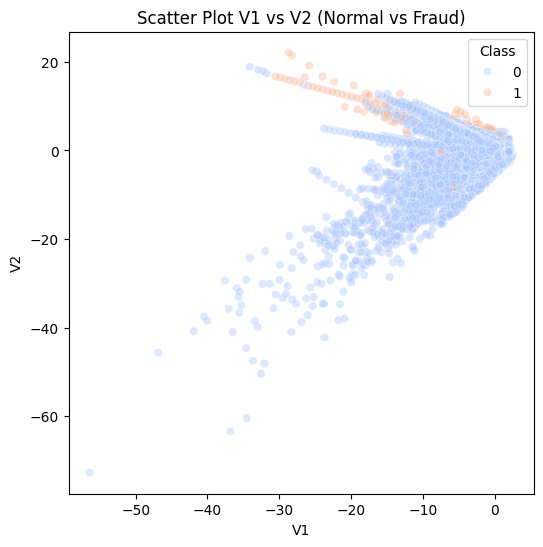

In [46]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='V1', y='V2', hue='Class', data=df_CC, alpha=0.4, palette='coolwarm')
plt.title("Scatter Plot V1 vs V2 (Normal vs Fraud)")
plt.show()


# Preprocessing

Scaling amount dan time

In [47]:
df_baru = df_CC.copy()

In [48]:
other_features = ['Time', 'Amount_winsorized']
import joblib

print("Robust scaling for 'Time' and 'Amount'...")
from sklearn.preprocessing import RobustScaler
scaler_robust = RobustScaler()

scaler_amount = RobustScaler()
df_CC['Amount_Scaled'] = scaler_amount.fit_transform(df_CC['Amount'].values.reshape(-1,1))

scaler_time = RobustScaler()
df_CC['Time_Scaled'] = scaler_time.fit_transform(df_CC['Time'].values.reshape(-1,1))

joblib.dump(scaler_amount, "scaler_ROBUS_amount.pkl")
joblib.dump(scaler_time, "scaler_ROBUS_time.pkl")

Robust scaling for 'Time' and 'Amount'...


['scaler_ROBUS_time.pkl']

Drop kolom asli (hindari redundant)

In [49]:
df_CC.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Amount_winsorized,hour,Amount_Scaled,Time_Scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,149.62,0.0,1.774718,-0.995290
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,2.69,0.0,-0.268530,-0.995290
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,378.66,0.0,4.959811,-0.995279
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,123.50,0.0,1.411487,-0.995279
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,69.99,0.0,0.667362,-0.995267


In [50]:
df_CC = df_CC.drop(['Amount', 'Time'], axis=1)
df_CC.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Class,Amount_winsorized,hour,Amount_Scaled,Time_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,149.62,0.0,1.774718,-0.995290
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,2.69,0.0,-0.268530,-0.995290
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,378.66,0.0,4.959811,-0.995279
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,123.50,0.0,1.411487,-0.995279
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,0,69.99,0.0,0.667362,-0.995267


train test split

In [51]:
from sklearn.model_selection import train_test_split

X = df_CC.drop('Class', axis=1)
y = df_CC['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Shape X_train:", X_train.shape)

Shape X_train: (226980, 32)


In [65]:
X_test.to_csv("X_test_CreditCard.csv", index=False)
y_test.to_csv("y_test_CreditCard.csv", index=False)

In [52]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))
print(f"\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

Training set shape: (226980, 32)
Testing set shape: (56746, 32)

Class distribution in training set:
Class
0    99.83%
1     0.17%
Name: proportion, dtype: object

Class distribution in testing set:
Class
0    99.83%
1     0.17%
Name: proportion, dtype: object


In [53]:
y_test.value_counts(), y_test.value_counts(normalize=True) * 100

(Class
 0    56651
 1       95
 Name: count, dtype: int64,
 Class
 0    99.832587
 1     0.167413
 Name: proportion, dtype: float64)

Tangani imbalanced class — gunakan SMOTE

In [54]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.1,random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [55]:
print(f"After SMOTE resampling:")
print(f"  Class 0 (Non-Fraud): {sum(y_train_res == 0)}")
print(f"  Class 1 (Fraud): {sum(y_train_res == 1)}")
print(f"  New ratio: {sum(y_train_res == 0)/sum(y_train_res == 1):.2f}:1")

After SMOTE resampling:
  Class 0 (Non-Fraud): 226602
  Class 1 (Fraud): 22660
  New ratio: 10.00:1


In [56]:
y_test.value_counts()


Class
0    56651
1       95
Name: count, dtype: int64

# Pemodelan

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr.fit(X_train_res, y_train_res)




LogisticRegression(class_weight='balanced', max_iter=2000)

In [58]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# evaluasi
print("=== Classification Report Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_lr))

print("\n=== AUC-ROC ===")
print(roc_auc_score(y_test, y_prob_lr))

=== Classification Report Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.08      0.87      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.57     56746
weighted avg       1.00      0.98      0.99     56746


=== Confusion Matrix ===
[[55666   985]
 [   12    83]]

=== AUC-ROC ===
0.9685384844788358


Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1,
                       random_state=42)

In [60]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=== Classification Report (RF) ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== Confusion Matrix (RF) ===")
print(confusion_matrix(y_test, y_pred_rf))

print("\n=== AUC-ROC (RF) ===")
print(roc_auc_score(y_test, y_prob_rf))

=== Classification Report (RF) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746


=== Confusion Matrix (RF) ===
[[56646     5]
 [   21    74]]

=== AUC-ROC (RF) ===
0.9797945685912545


In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Rasio kelas untuk scale_pos_weight
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    scale_pos_weight=ratio,     # sangat penting!
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=700, n_jobs=-1,
              num_parallel_tree=None, ...)

In [62]:
# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Classification Report (XGBoost) ===")
print(classification_report(y_test, y_pred_xgb))

print("\n=== Confusion Matrix (XGBoost) ===")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n=== AUC-ROC (XGBoost) ===")
print(roc_auc_score(y_test, y_prob_xgb))

=== Classification Report (XGBoost) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.78      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746


=== Confusion Matrix (XGBoost) ===
[[56649     2]
 [   21    74]]

=== AUC-ROC (XGBoost) ===
0.9810892918692381


In [72]:
import pandas as pd

# Pastikan X_test adalah DataFrame
results_df = X_test.copy()

# Tambahkan label actual & hasil prediksi
results_df['actual'] = y_test.values
results_df['predicted'] = y_pred_xgb
results_df['fraud_probability'] = y_prob_xgb

results_df['prediction_result'] = 'TN'

results_df.loc[
    (results_df.actual == 1) & (results_df.predicted == 1),
    'prediction_result'
] = 'TP'

results_df.loc[
    (results_df.actual == 0) & (results_df.predicted == 1),
    'prediction_result'
] = 'FP'

results_df.loc[
    (results_df.actual == 1) & (results_df.predicted == 0),
    'prediction_result'
] = 'FN'


In [73]:
results_df.to_csv(
    "creditcard_xgboost_predictions_full.csv",
    index=False
)


In [63]:
import joblib

joblib.dump(xgb, "xgboost_fraud_model_CreditCard.pkl")

['xgboost_fraud_model_CreditCard.pkl']

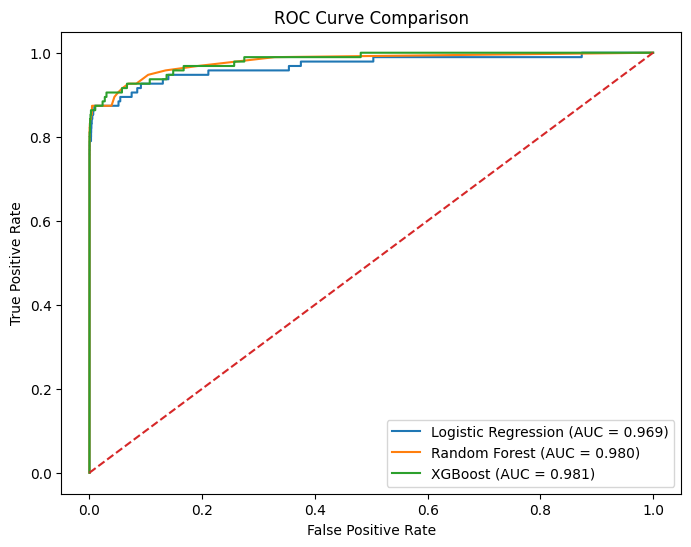

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Hitung ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()
